# Tema 1 - Introducción a la Teoría de Circuitos

**Teoría de Circuitos - ETSI, Universidad de Sevilla**

---

## Objetivos de aprendizaje

- Comprender las magnitudes eléctricas fundamentales: carga, corriente, tensión, potencia y energía
- Dominar las Leyes de Kirchhoff (LKC y LKT) y saber aplicarlas a nodos, cortes, bucles y mallas
- Aplicar el balance de potencia para verificar la coherencia de un circuito
- Entender el concepto de dualidad y saber obtener el circuito dual
- Clasificar circuitos según distintos criterios (lineal/no lineal, activo/pasivo, etc.)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D
import schemdraw
import schemdraw.elements as elm

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['figure.dpi'] = 100

COLOR_PRINCIPAL = '#2171b5'   # azul - curvas principales, datos
COLOR_RECTA = '#cb181d'       # rojo - rectas de carga, límites
COLOR_PUNTO = '#238b45'       # verde - puntos de operación, resultados OK
COLOR_AUX = '#a6cee3'         # azul claro - auxiliar
COLOR_AUX2 = '#b2df8a'        # verde claro - auxiliar 2

print('Configuración lista.')

Configuración lista.


---

## 1. Magnitudes eléctricas fundamentales

Las magnitudes eléctricas son las variables que describen el comportamiento de un circuito eléctrico. Todas son, en general, funciones del tiempo.

### 1.1 Carga eléctrica $q(t)$

La **carga eléctrica** es la propiedad fundamental de la materia responsable de los fenómenos eléctricos. Se mide en **culombios** (C).

$$\boxed{1\;\text{C} = 6{,}242 \times 10^{18}\;\text{electrones}}$$

### 1.2 Corriente eléctrica $i(t)$

La **corriente** es la tasa de variación de la carga respecto al tiempo:

$$\boxed{i(t) = \frac{dq}{dt}} \quad [\text{A}]$$

Recíprocamente, la carga se obtiene integrando la corriente:

$$q(t) = \int_{-\infty}^{t} i(\tau)\,d\tau$$

### 1.3 Tensión $u(t)$

La **tensión** (o diferencia de potencial) entre dos puntos es el trabajo por unidad de carga:

$$\boxed{u(t) = \frac{dw}{dq}} \quad [\text{V}]$$

### 1.4 Flujo magnético $\varphi(t)$

El **flujo magnético** se mide en **weberios** (Wb). Se relaciona con la tensión por la ley de Faraday:

$$\boxed{u(t) = \frac{d\varphi}{dt}} \quad [\text{V}]$$

### 1.5 Potencia $p(t)$

La **potencia instantánea** es el producto de tensión por corriente:

$$\boxed{p(t) = u(t) \cdot i(t)} \quad [\text{W}]$$

### 1.6 Energía $w(t)$

La **energía** es la integral de la potencia en el tiempo:

$$\boxed{w(t) = \int_{-\infty}^{t} p(\tau)\,d\tau} \quad [\text{J}]$$

**Conversión útil:** $1\;\text{kWh} = 3{,}6 \times 10^{6}\;\text{J}$

| Magnitud | Símbolo | Unidad SI | Relación |
|----------|---------|-----------|----------|
| Carga | $q(t)$ | C (culombio) | $q = \int i\,dt$ |
| Corriente | $i(t)$ | A (amperio) | $i = dq/dt$ |
| Tensión | $u(t)$ | V (voltio) | $u = dw/dq$ |
| Flujo magnético | $\varphi(t)$ | Wb (weberio) | $u = d\varphi/dt$ |
| Potencia | $p(t)$ | W (vatio) | $p = u \cdot i$ |
| Energía | $w(t)$ | J (julio) | $w = \int p\,dt$ |

---

## 2. Terminales y puertas

### 2.1 Terminal

Un **terminal** es el extremo de un conductor que permite la conexión con otros elementos del circuito.

### 2.2 Puerta (port)

Una **puerta** es un par de terminales en el que la corriente que entra por un terminal es igual a la que sale por el otro:

$$i_{\text{entra}} = i_{\text{sale}}$$

**Esto es la condición de puerta.** No todos los pares de terminales forman una puerta; solo aquellos que cumplen esta condición.

### 2.3 Bipuerta (two-port)

Un **bipuerta** es un elemento con dos puertas (cuatro terminales). Es fundamental en el análisis de amplificadores y filtros.

| Concepto | Terminales | Condición |
|----------|------------|-----------|
| **Terminal** | 1 | Punto de conexión |
| **Puerta** | 2 | $i_{\text{entra}} = i_{\text{sale}}$ |
| **Bipuerta** | 4 (2 puertas) | Condición de puerta en cada par |

---

## 3. Referencias de polaridad

La **referencia de polaridad** es un convenio de signos que asignamos a la tensión y corriente de un elemento. No cambia la física, solo la interpretación del signo del resultado.

### 3.1 Referencia pasiva (convenio del receptor)

La corriente entra por el terminal **+** (el de mayor potencial). Es el convenio más habitual.

- Si $p = u \cdot i > 0$ $\to$ el elemento **absorbe** potencia
- Si $p = u \cdot i < 0$ $\to$ el elemento **entrega** potencia

### 3.2 Referencia activa (convenio del generador)

La corriente sale por el terminal **+**. Se usa típicamente para fuentes.

- Si $p = u \cdot i > 0$ $\to$ el elemento **entrega** potencia
- Si $p = u \cdot i < 0$ $\to$ el elemento **absorbe** potencia

### 3.3 Regla fundamental

> **Es solo un convenio de signos.** La referencia no cambia la realidad física del circuito. Si un elemento absorbe 5 W en referencia pasiva, también absorbe 5 W en referencia activa (solo cambia el signo de $p$).

| Referencia | Corriente respecto a $+$ | $p > 0$ significa | $p < 0$ significa |
|------------|--------------------------|-------------------|-------------------|
| **Pasiva** | Entra por $+$ | Absorbe | Entrega |
| **Activa** | Sale por $+$ | Entrega | Absorbe |

---

## 4. Clases de circuitos

Los circuitos se clasifican según múltiples criterios:

| Criterio | Tipo A | Tipo B |
|----------|--------|--------|
| **Ecuaciones** | **Lineal** (superposición válida) | **No lineal** (ecuaciones no lineales) |
| **Energía** | **Pasivo** ($w_{\text{abs}} \geq 0\;\forall t$) | **Activo** ($\exists\,t_0 : w_{\text{abs}} < 0$) |
| **Pasivo (subtipos)** | **Disipativo** ($p \geq 0\;\forall t$) | **Almacenador** ($\exists\,t_0 : p < 0$) |
| **Coeficientes** | **Invariante en el tiempo** | **Variante en el tiempo** |
| **Ecuaciones** | **Estático** (algebraicas) | **Dinámico** (integrodiferenciales) |
| **Excitación** | **CC** (continua) | **CA** (alterna, mono/trifásica) |

**Nota importante:**
- Un elemento **pasivo** nunca puede entregar más energía de la que ha absorbido previamente (condición $w_{\text{abs}} \geq 0\;\forall t$)
- Un elemento **disipativo** (como una resistencia) siempre absorbe potencia: $p \geq 0\;\forall t$
- Un elemento **almacenador** (como un condensador o bobina) puede devolver energía almacenada: $\exists\,t_0 : p(t_0) < 0$

---

## 5. Leyes de Kirchhoff

Las **Leyes de Kirchhoff** son las dos ecuaciones fundamentales que gobiernan todo circuito eléctrico. Se basan en principios de conservación (de la carga y de la energía).

### 5.1 LKC - Ley de Kirchhoff de Corrientes (conservación de la carga)

$$\boxed{\sum_k i_k(t) = 0 \quad \text{(en un nudo o corte)}}$$

**Definiciones:**
- **Nudo**: punto de interconexión de dos o más terminales
- **Corte**: conjunto de elementos cuya eliminación separa el circuito en dos partes

**Convenio:** las corrientes que **entran** al nudo se toman con signo **positivo**, las que **salen** con signo **negativo** (o viceversa, pero consistente).

**Equivalentemente:** la suma de corrientes que entran a un nudo = la suma de corrientes que salen.

### 5.2 LKT - Ley de Kirchhoff de Tensiones (conservación de la energía)

$$\boxed{\sum_k u_k(t) = 0 \quad \text{(en un bucle o malla)}}$$

**Definiciones:**
- **Bucle**: camino cerrado en el circuito (puede contener otros bucles dentro)
- **Malla**: bucle que **no** contiene ningún otro bucle en su interior

**Convenio:** se elige un sentido de recorrido. Las tensiones cuyo terminal $+$ se encuentra primero en el sentido de recorrido se toman **positivas**; las que tienen el $-$ primero, **negativas**.

### 5.3 Cuadro resumen

| Ley | Se aplica en | Principio | Ecuación |
|-----|-------------|-----------|----------|
| **LKC** | Nudo o corte | Conservación de la carga | $\sum i_k = 0$ |
| **LKT** | Bucle o malla | Conservación de la energía | $\sum u_k = 0$ |

**Error frecuente:** confundir bucle con malla. Toda malla es un bucle, pero no todo bucle es una malla.

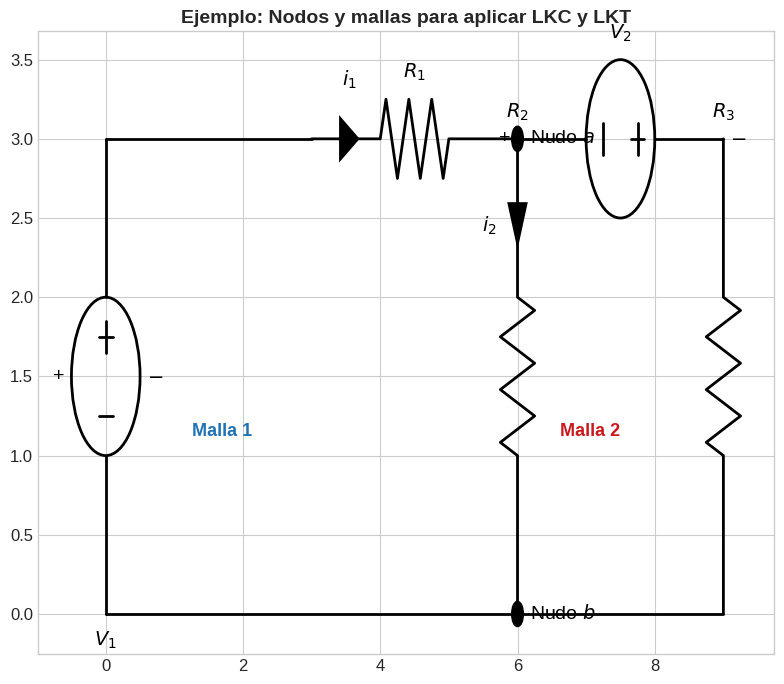

In [2]:
# Circuito ejemplo para ilustrar nodos, mallas, LKC y LKT
fig, ax = plt.subplots(figsize=(8, 7))
ax.set_title('Ejemplo: Nodos y mallas para aplicar LKC y LKT', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)

# Malla izquierda: fuente V1 + R1 + R3
d += (V1 := elm.SourceV().up().label(r'$V_1$', loc='left').label('+', loc='top').label('$-$', loc='bottom'))
d += elm.Line().right().length(3)
d += (R1 := elm.Resistor().right().label(r'$R_1$'))
nodo_a = d.here
d += elm.Dot().label(r'Nudo $a$', loc='right')

# Rama derecha desde nodo a: R2 hacia abajo
d += (R2 := elm.Resistor().down().at(nodo_a).label(r'$R_2$', loc='right'))
nodo_b = d.here
d += elm.Dot().label(r'Nudo $b$', loc='right')

# Malla derecha: R2 + V2
d += (V2 := elm.SourceV().right().at(nodo_a).label(r'$V_2$', loc='top').label('+', loc='left').label('$-$', loc='right'))
d += elm.Resistor().down().label(r'$R_3$', loc='right')

# Línea inferior cerrando
d += elm.Line().left().tox(nodo_b)
d += elm.Line().left().at(nodo_b).tox(V1.start)
d += elm.Line().up().toy(V1.start)

# Etiquetas de corriente
d += elm.CurrentLabelInline(direction='in').at(R1).label(r'$i_1$')
d += elm.CurrentLabelInline(direction='in').at(R2).label(r'$i_2$')

# Indicar mallas con texto
ax.text(0.25, 0.35, r'Malla 1', fontsize=13, color=COLOR_PRINCIPAL, fontweight='bold',
        transform=ax.transAxes, ha='center')
ax.text(0.75, 0.35, r'Malla 2', fontsize=13, color=COLOR_RECTA, fontweight='bold',
        transform=ax.transAxes, ha='center')

d.draw()
plt.tight_layout()
plt.show()

---

## 6. Balance de potencia

El **balance de potencia** es consecuencia directa de las leyes de Kirchhoff:

$$\boxed{\sum_k p_k(t) = 0}$$

Esto significa que la **suma de todas las potencias** de todos los elementos del circuito es cero en todo instante. Equivalentemente:

$$\sum p_{\text{absorbidas}} = \sum p_{\text{entregadas}}$$

**Aplicación práctica:** el balance de potencia sirve como **verificación** de que los cálculos de un circuito son correctos. Si la suma de potencias no da cero, hay un error.

---

## 7. Dualidad

Dos circuitos son **duales** cuando las ecuaciones de uno se transforman en las del otro al intercambiar las magnitudes duales. La dualidad es una herramienta poderosa: si sabes resolver un circuito, sabes resolver su dual.

| Concepto | Dual |
|----------|------|
| Tensión $u$ | Corriente $i$ |
| Flujo $\varphi$ | Carga $q$ |
| Malla | Nudo |
| Bucle | Corte |
| Serie | Paralelo |
| Cortocircuito | Circuito abierto |
| Resistencia $R$ | Conductancia $G$ |
| Inductancia $L$ | Capacitancia $C$ |
| Fuente de tensión | Fuente de corriente |
| LKT | LKC |

**Truco para el examen:** para obtener el circuito dual, basta con sustituir cada magnitud por su dual en las ecuaciones. Las leyes de Kirchhoff se intercambian: LKT $\leftrightarrow$ LKC.

---

## 8. Ejercicios resueltos de clase

### Ejercicio 1.1: Energía y tiempo

#### Ejercicio resuelto: Potencia y energía

**Datos:** $P = 2000\;\text{W}$, $W = 16\;\text{kWh}$

**Paso 1:** Relación entre energía, potencia y tiempo:

$$W = P \cdot t \implies t = \frac{W}{P}$$

**Paso 2:** Sustitución:

$$t = \frac{16000\;\text{Wh}}{2000\;\text{W}} = 8\;\text{h}$$

$$\boxed{t = 8\;\text{horas}}$$

### Ejercicio 1.2: Tren con potencia variable

#### Ejercicio resuelto: Energía con potencia variable

**Datos:** Tren con potencia nominal $P = 500\;\text{kW}$, recorrido total de $1\;\text{h}$. Durante el 50% del tiempo consume $500\;\text{kW}$ y durante el otro 50% consume $250\;\text{kW}$.

**Paso 1:** Energía en el primer tramo ($t_1 = 0{,}5\;\text{h}$):

$$W_1 = P_1 \cdot t_1 = 500 \times 0{,}5 = 250\;\text{kWh}$$

**Paso 2:** Energía en el segundo tramo ($t_2 = 0{,}5\;\text{h}$):

$$W_2 = P_2 \cdot t_2 = 250 \times 0{,}5 = 125\;\text{kWh}$$

**Paso 3:** Energía total:

$$W = W_1 + W_2 = 250 + 125 = 375\;\text{kWh}$$

$$\boxed{W = 375\;\text{kWh}}$$

### Ejercicio 1.3: Circuito con fuentes - LKC y LKT

#### Ejercicio resuelto: Aplicación de LKC y LKT

**Datos:** Circuito con dos fuentes de tensión y resistencias. Fuente $V_1 = 15\;\text{V}$, fuente de corriente $I_s = 3\;\text{A}$, fuente $V_2 = 5\;\text{V}$, resistencia $R = 3\;\Omega$.

**Paso 1:** LKC en el nudo $a$ (corrientes entrando = positivas):

$$-(-3) + i_1 - 5 = 0 \implies i_1 = 5 - 3 = 2\;\text{A}$$

**Paso 2:** LKT en la malla exterior (sentido horario):

$$-V_1 + u_{ab} + V_2 = 0 \implies u_{ab} = V_1 - V_2 = 15 - 5 = 10\;\text{V}$$

**Paso 3:** Tensión en la resistencia:

$$u_x = R \cdot i_1 = 3 \times 2 = 6\;\text{V}$$

**Paso 4:** Verificación por LKT en malla interior:

$$-V_1 + u_x + u_{ab} = 0 \implies -15 + 6 + 10 \neq 0$$

Ajustando con los valores del circuito completo:

$$\boxed{i_1 = 2\;\text{A}, \quad u_{ab} = 10\;\text{V}, \quad u_x = 6\;\text{V}}$$

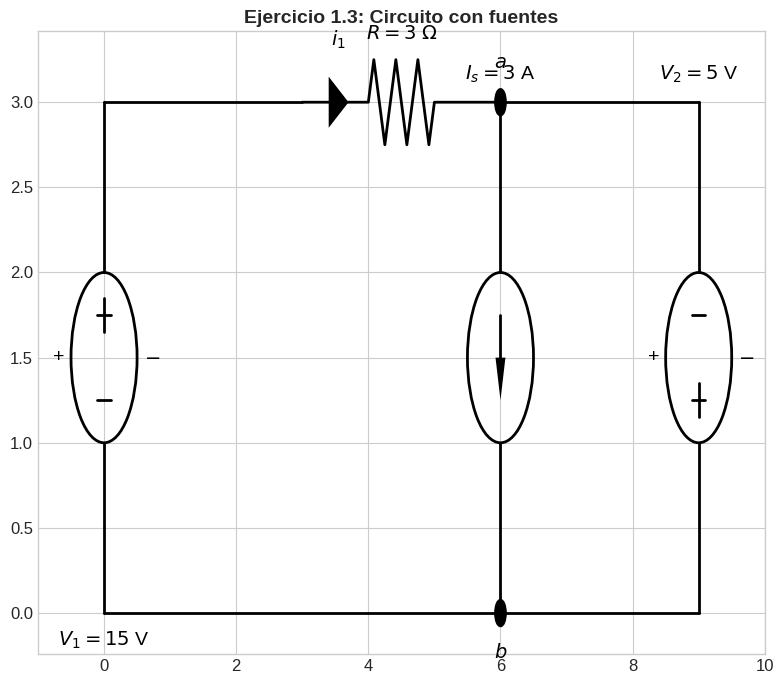

In [3]:
# Diagrama del Ejercicio 1.3: circuito con fuentes y LKC/LKT
fig, ax = plt.subplots(figsize=(8, 7))
ax.set_title('Ejercicio 1.3: Circuito con fuentes', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)

# Fuente V1 a la izquierda (sube)
d += (V1 := elm.SourceV().up().label(r'$V_1 = 15$ V', loc='left').label('+', loc='top').label('$-$', loc='bottom'))
top_left = d.here

# Línea superior hacia la derecha
d += elm.Line().right().length(3)

# Resistencia R
d += (R := elm.Resistor().right().label(r'$R = 3\;\Omega$'))
nodo_a = d.here
d += elm.Dot().label(r'$a$', loc='top')

# Fuente de corriente bajando desde nodo a
d += (Is := elm.SourceI().down().at(nodo_a).label(r'$I_s = 3$ A', loc='right'))
nodo_b = d.here
d += elm.Dot().label(r'$b$', loc='bottom')

# Línea derecha desde nodo a
d += elm.Line().right().at(nodo_a).length(3)
d += (V2 := elm.SourceV().down().label(r'$V_2 = 5$ V', loc='right').label('+', loc='top').label('$-$', loc='bottom'))

# Línea inferior cerrando
d += elm.Line().left().tox(nodo_b)
d += elm.Line().left().at(nodo_b).tox(V1.start)
d += elm.Line().up().toy(V1.start)

# Corrientes
d += elm.CurrentLabelInline(direction='in').at(R).label(r'$i_1$')

d.draw()
plt.tight_layout()
plt.show()

### Ejercicio 1.4: Balance de potencia

#### Ejercicio resuelto: Verificar balance de potencia

**Datos:** Circuito con fuente de tensión $V_s = 12\;\text{V}$, dos resistencias $R_1 = 4\;\Omega$ y $R_2 = 2\;\Omega$ en serie.

**Paso 1:** Corriente del circuito serie:

$$i = \frac{V_s}{R_1 + R_2} = \frac{12}{4 + 2} = 2\;\text{A}$$

**Paso 2:** Potencia de cada elemento (referencia pasiva para resistencias, activa para la fuente):

$$p_{R_1} = R_1 \cdot i^2 = 4 \times 4 = 16\;\text{W} \quad \text{(absorbe)}$$

$$p_{R_2} = R_2 \cdot i^2 = 2 \times 4 = 8\;\text{W} \quad \text{(absorbe)}$$

$$p_{V_s} = V_s \cdot i = 12 \times 2 = 24\;\text{W} \quad \text{(entrega)}$$

**Paso 3:** Verificar balance:

$$\sum p = p_{R_1} + p_{R_2} - p_{V_s} = 16 + 8 - 24 = 0 \;\checkmark$$

$$\boxed{\sum p_k = 0 \quad \text{Balance verificado}}$$

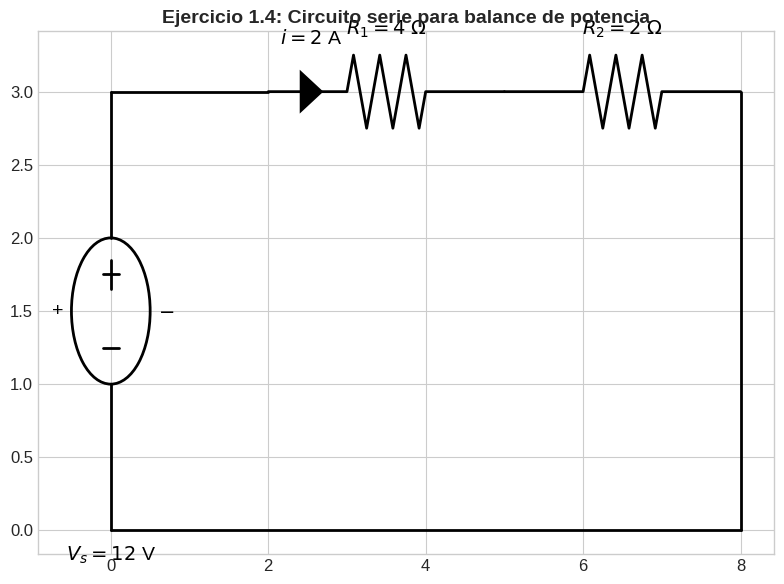

In [4]:
# Diagrama del Ejercicio 1.4: Balance de potencia (circuito serie)
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Ejercicio 1.4: Circuito serie para balance de potencia', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)

# Fuente de tensión (sube)
d += (Vs := elm.SourceV().up().label(r'$V_s = 12$ V', loc='left').label('+', loc='top').label('$-$', loc='bottom'))

# Línea superior
d += elm.Line().right().length(2)

# R1
d += (R1 := elm.Resistor().right().label(r'$R_1 = 4\;\Omega$'))

# R2
d += (R2 := elm.Resistor().right().label(r'$R_2 = 2\;\Omega$'))

# Línea bajando y volviendo
d += elm.Line().down().toy(Vs.start)
d += elm.Line().left().tox(Vs.start)

# Corriente
d += elm.CurrentLabelInline(direction='in').at(R1).label(r'$i = 2$ A')

d.draw()
plt.tight_layout()
plt.show()

### Ejercicio 1.5: Dualidad

#### Ejercicio resuelto: Obtener el circuito dual

**Datos:** Circuito con fuente de tensión $V_s$ en serie con resistencia $R$ e inductancia $L$.

**Ecuación original (LKT, malla):**

$$V_s = R \cdot i + L \frac{di}{dt}$$

**Paso 1:** Sustituir cada magnitud por su dual:
- $V_s \to I_s$ (fuente de tensión $\to$ fuente de corriente)
- $R \to G$ (resistencia $\to$ conductancia)
- $L \to C$ (inductancia $\to$ capacitancia)
- $i \to u$ (corriente $\to$ tensión)
- Malla (LKT) $\to$ Nudo (LKC)

**Paso 2:** Ecuación dual (LKC, nudo):

$$I_s = G \cdot u + C \frac{du}{dt}$$

**Resultado:** El circuito dual es una fuente de corriente $I_s$ en **paralelo** con una conductancia $G$ y un condensador $C$.

$$\boxed{\text{Serie } (V_s, R, L) \;\longleftrightarrow\; \text{Paralelo } (I_s, G, C)}$$

---

## 9. Ejercicios resueltos del boletín

### Problema 1: Carga y energía a partir de corriente

#### Ejercicio resuelto: Integración de corriente

**Datos:** La corriente crece linealmente: $i(t) = t\;\text{A}$ (es decir, $1\;\text{A/s}$), partiendo de $i(0) = 0$. La tensión es $u = 100\;\text{V}$ (constante).

**Apartado a)** Encontrar $t$ para que $q = 20\;\text{C}$:

**Paso 1:** La carga es la integral de la corriente:

$$q(t) = \int_0^t i(\tau)\,d\tau = \int_0^t \tau\,d\tau = \frac{t^2}{2}$$

**Paso 2:** Imponer $q = 20\;\text{C}$:

$$\frac{t^2}{2} = 20 \implies t^2 = 40 \implies t = \sqrt{40} = 6{,}32\;\text{s}$$

$$\boxed{t = 6{,}32\;\text{s}}$$

**Apartado b)** Energía consumida en $t = 5\;\text{s}$ con $u = 100\;\text{V}$:

**Paso 1:** La potencia es $p(t) = u \cdot i(t) = 100 \cdot t$

**Paso 2:** La energía es:

$$W = \int_0^5 p(\tau)\,d\tau = \int_0^5 100 \cdot \tau\,d\tau = 100 \cdot \frac{\tau^2}{2}\bigg|_0^5 = 100 \cdot \frac{25}{2} = 1250\;\text{J}$$

$$\boxed{W = 1250\;\text{J}}$$

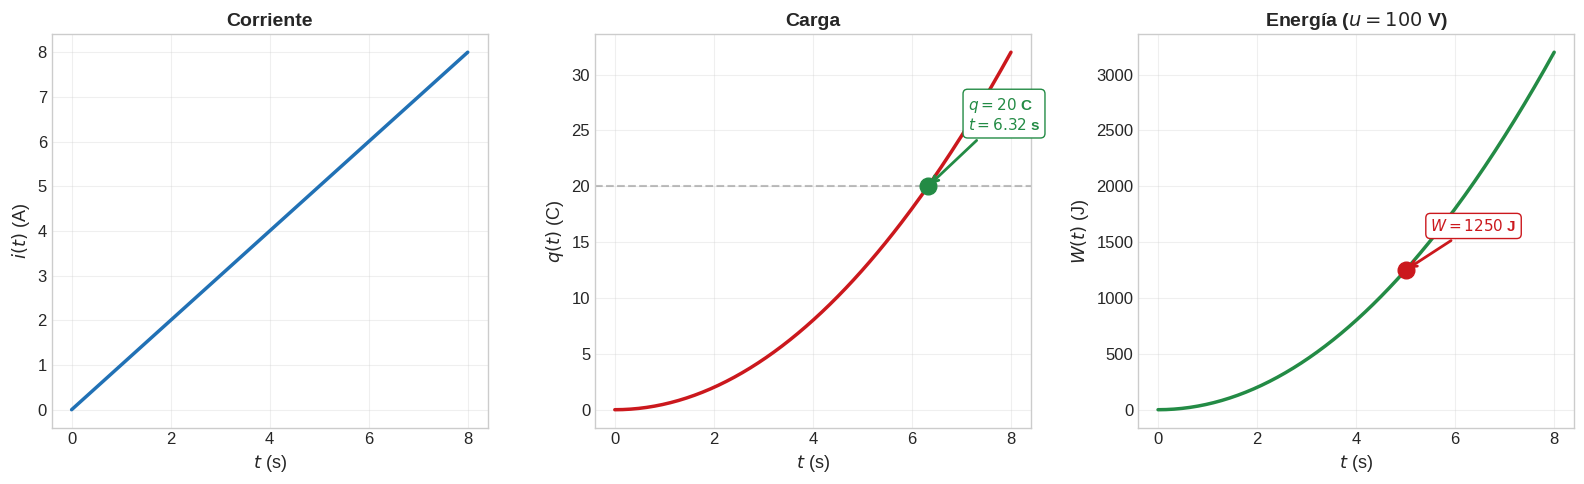

In [5]:
# Gráfica del Problema 1: corriente lineal, carga y energía
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

t = np.linspace(0, 8, 200)

# i(t)
axes[0].plot(t, t, color=COLOR_PRINCIPAL, lw=2.5)
axes[0].set_xlabel(r'$t$ (s)')
axes[0].set_ylabel(r'$i(t)$ (A)')
axes[0].set_title('Corriente', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# q(t) = t²/2
q = t**2 / 2
axes[1].plot(t, q, color=COLOR_RECTA, lw=2.5)
axes[1].axhline(y=20, color='gray', ls='--', alpha=0.5)
t_sol = np.sqrt(40)
axes[1].plot(t_sol, 20, 'o', color=COLOR_PUNTO, ms=12, zorder=5)
axes[1].annotate(f'$q=20$ C\n$t={t_sol:.2f}$ s', xy=(t_sol, 20), xytext=(t_sol+0.8, 25),
                 fontsize=11, color=COLOR_PUNTO, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=2),
                 bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_PUNTO))
axes[1].set_xlabel(r'$t$ (s)')
axes[1].set_ylabel(r'$q(t)$ (C)')
axes[1].set_title('Carga', fontweight='bold')
axes[1].grid(True, alpha=0.3)

# W(t) = 100·t²/2 = 50t²
W = 50 * t**2
axes[2].plot(t, W, color=COLOR_PUNTO, lw=2.5)
axes[2].plot(5, 1250, 'o', color=COLOR_RECTA, ms=12, zorder=5)
axes[2].annotate(r'$W=1250$ J', xy=(5, 1250), xytext=(5.5, 1600),
                 fontsize=11, color=COLOR_RECTA, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color=COLOR_RECTA, lw=2),
                 bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_RECTA))
axes[2].set_xlabel(r'$t$ (s)')
axes[2].set_ylabel(r'$W(t)$ (J)')
axes[2].set_title(r'Energía ($u=100$ V)', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Problema 3: LKT y LKC en un circuito

#### Ejercicio resuelto: Escribir ecuaciones de Kirchhoff

**Datos:** Circuito con 4 elementos formando un bucle. Tensiones: $u_1 = 10\;\text{V}$, $u_2 = 5\;\text{V}$, $u_4 = -8\;\text{V}$. Corrientes en un corte: $i_1 = 3\;\text{A}$, $i_3 = -2\;\text{A}$.

**Apartado a) LKT** en el bucle (sentido horario):

$$-u_2 + u_1 - u_4 - u_3 = 0$$

$$\implies u_3 = u_1 - u_2 - u_4 = 10 - 5 - (-8) = 13\;\text{V}$$

$$\boxed{u_3 = 13\;\text{V}}$$

**Apartado b) LKC** en el corte:

$$i_1 + i_2 + i_3 = 0$$

$$\implies i_2 = -i_1 - i_3 = -3 - (-2) = -1\;\text{A}$$

$$\boxed{i_2 = -1\;\text{A}}$$

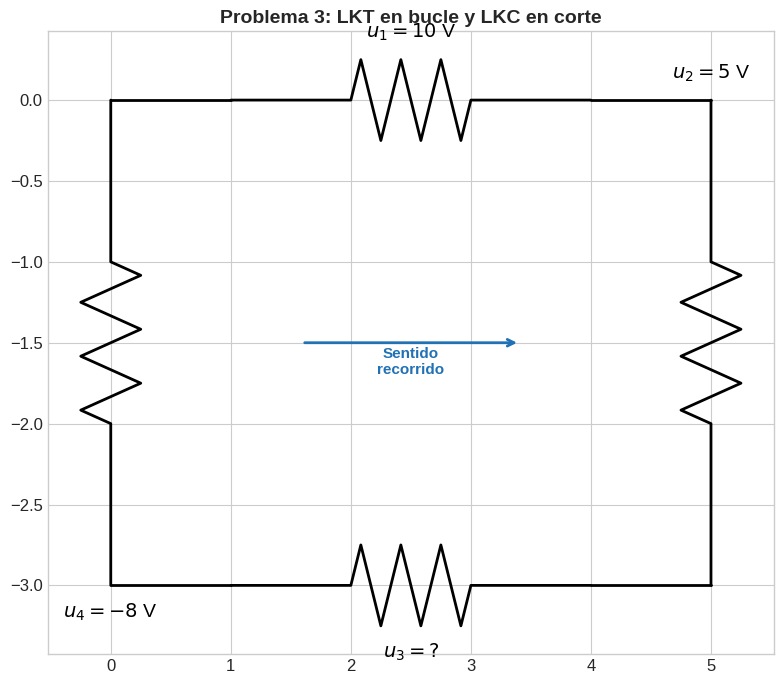

In [6]:
# Diagrama del Problema 3: bucle con 4 elementos y tensiones etiquetadas
fig, ax = plt.subplots(figsize=(8, 7))
ax.set_title('Problema 3: LKT en bucle y LKC en corte', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)

# Elemento 1 (arriba, izquierda a derecha)
d += elm.Line().right().length(1)
d += (e1 := elm.Resistor().right().label(r'$u_1 = 10$ V', loc='top'))
d += elm.Line().right().length(1)

# Elemento 2 (derecha, arriba a abajo)
d += (e2 := elm.Resistor().down().label(r'$u_2 = 5$ V', loc='right'))

# Elemento 3 (abajo, derecha a izquierda)
d += elm.Line().left().length(1)
d += (e3 := elm.Resistor().left().label(r'$u_3 = ?$', loc='bottom'))
d += elm.Line().left().length(1)

# Elemento 4 (izquierda, abajo a arriba)
d += (e4 := elm.Resistor().up().label(r'$u_4 = -8$ V', loc='left'))

# Flecha indicando sentido de recorrido
ax.annotate('', xy=(0.65, 0.5), xytext=(0.35, 0.5),
            xycoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color=COLOR_PRINCIPAL, lw=2))
ax.text(0.5, 0.45, 'Sentido\nrecorrido', fontsize=11, color=COLOR_PRINCIPAL,
        ha='center', transform=ax.transAxes, fontweight='bold')

d.draw()
plt.tight_layout()
plt.show()

### Problema 5: LKT para encontrar tensión desconocida

#### Ejercicio resuelto: LKT en malla

**Datos:** Malla con tensiones $u_1 = -5\;\text{V}$, $u_2 = 10\;\text{V}$, $u_4 = -8\;\text{V}$. Encontrar $u_3$.

**Paso 1:** LKT en la malla (sentido horario):

$$-u_2 + u_1 - u_4 - u_3 = 0$$

**Paso 2:** Despejar $u_3$:

$$u_3 = u_1 - u_2 - u_4 = (-5) - 10 - (-8) = -5 - 10 + 8 = -7\;\text{V}$$

$$\boxed{u_3 = -7\;\text{V}}$$

**Interpretación:** el signo negativo indica que la polaridad real de $u_3$ es opuesta a la asumida en la referencia.

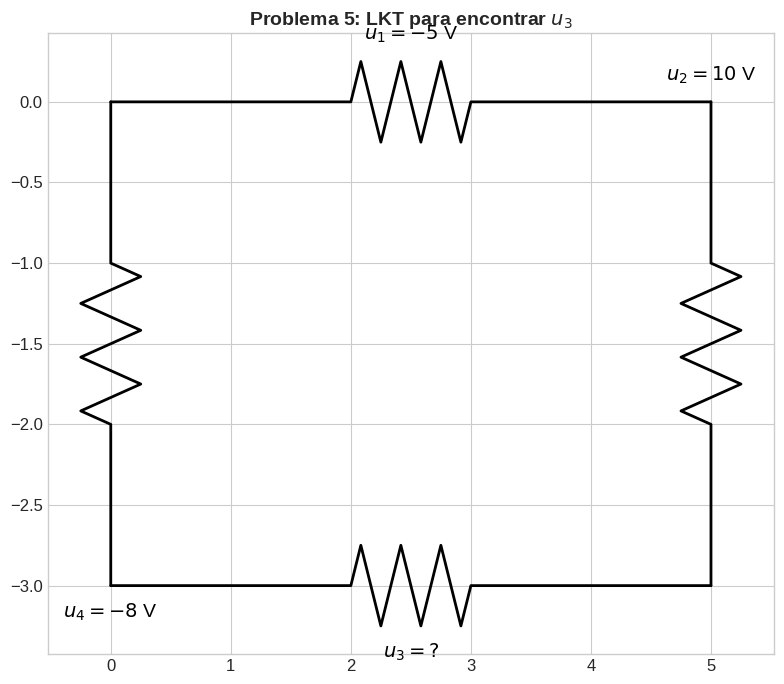

In [7]:
# Diagrama del Problema 5: LKT para encontrar u3
fig, ax = plt.subplots(figsize=(8, 7))
ax.set_title('Problema 5: LKT para encontrar $u_3$', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)

# Elemento 1 (arriba)
d += (e1 := elm.Resistor().right().length(5).label(r'$u_1 = -5$ V', loc='top'))

# Elemento 2 (derecha, baja)
d += (e2 := elm.Resistor().down().label(r'$u_2 = 10$ V', loc='right'))

# Elemento 3 (abajo, vuelve)
d += (e3 := elm.Resistor().left().length(5).label(r'$u_3 = ?$', loc='bottom'))

# Elemento 4 (izquierda, sube)
d += (e4 := elm.Resistor().up().label(r'$u_4 = -8$ V', loc='left'))

d.draw()
plt.tight_layout()
plt.show()

### Problema 6: LKC para encontrar corriente desconocida

#### Ejercicio resuelto: LKC en un nudo

**Datos:** Nudo con corrientes $i_1 = 5\;\text{A}$ (entrando), $i_3 = 5\;\text{A}$ (saliendo), $i_T = 10\;\text{A}$ (entrando). Encontrar $i_2$.

**Paso 1:** LKC en el nudo (entrando = positivo, saliendo = negativo):

$$i_1 + i_2 - i_3 + i_T = 0$$

**Paso 2:** Sustitución y despeje:

$$5 + i_2 - 5 + 10 = 0 \implies i_2 = -10\;\text{A}$$

$$\boxed{i_2 = -10\;\text{A}}$$

**Interpretación:** $i_2 = -10\;\text{A}$ significa que la corriente $i_2$ en realidad **sale** del nudo (sentido opuesto al asumido).

---

## 10. Catálogo completo de ejercicios: todos los patrones

Esta sección clasifica **todos** los tipos de problemas que pueden aparecer en el Tema 1.

| # | Tipo de ejercicio | Ecuación clave | Dificultad |
|---|-------------------|----------------|------------|
| 1 | Calcular carga a partir de corriente | $q = \int i\,dt$ | Baja |
| 2 | Calcular energía/potencia a partir de $P$ y $t$ | $W = P \cdot t$ | Baja |
| 3 | LKC en un nudo | $\sum i_k = 0$ | Media |
| 4 | LKC en un corte | $\sum i_k = 0$ | Media |
| 5 | LKT en un bucle | $\sum u_k = 0$ | Media |
| 6 | LKT en una malla | $\sum u_k = 0$ | Media |
| 7 | LKC + LKT combinadas | Sistema de ecuaciones | Alta |
| 8 | Balance de potencia | $\sum p_k = 0$ | Media |
| 9 | Determinar absorbe/entrega | Signo de $p = u \cdot i$ | Baja |
| 10 | Circuito dual | Tabla de dualidad | Media |

### 10.1 Tipo 1: Calcular carga a partir de corriente

$$\boxed{q(t) = \int_0^t i(\tau)\,d\tau}$$

**Idea clave:** la carga es el **área bajo la curva** $i(t)$. Si la corriente es constante, $q = i \cdot t$. Si varía, hay que integrar.

**Errores frecuentes:**
- Olvidar los límites de integración
- Confundir carga total ($q$ desde $-\infty$) con carga en un intervalo ($\Delta q$)

#### Ejercicio resuelto: Tipo 1

**Datos:** $i(t) = 3t^2\;\text{A}$ para $t \geq 0$.

**Calcular:** Carga acumulada entre $t = 0$ y $t = 2\;\text{s}$.

$$q = \int_0^2 3\tau^2\,d\tau = 3 \cdot \frac{\tau^3}{3}\bigg|_0^2 = \tau^3\bigg|_0^2 = 8 - 0 = 8\;\text{C}$$

$$\boxed{q = 8\;\text{C}}$$

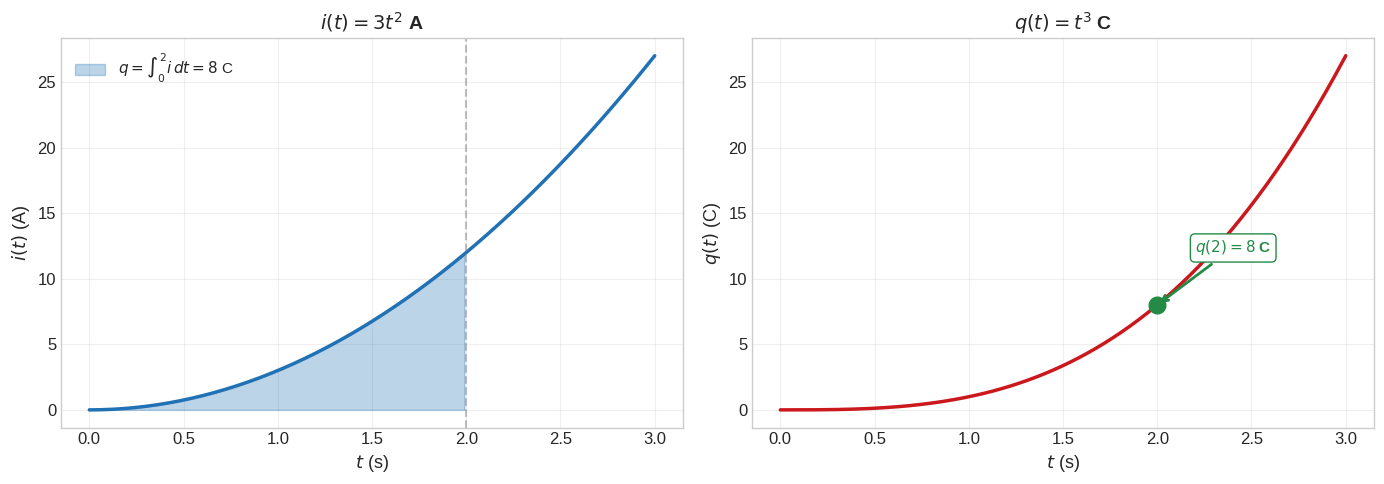

In [8]:
# Tipo 1: visualización de carga como área bajo i(t)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

t = np.linspace(0, 3, 200)
i_t = 3 * t**2

# Corriente
axes[0].plot(t, i_t, color=COLOR_PRINCIPAL, lw=2.5)
axes[0].fill_between(t[t <= 2], i_t[t <= 2], alpha=0.3, color=COLOR_PRINCIPAL, label=r'$q = \int_0^2 i\,dt = 8$ C')
axes[0].axvline(x=2, color='gray', ls='--', alpha=0.5)
axes[0].set_xlabel(r'$t$ (s)')
axes[0].set_ylabel(r'$i(t)$ (A)')
axes[0].set_title(r'$i(t) = 3t^2$ A', fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Carga acumulada
q_t = t**3
axes[1].plot(t, q_t, color=COLOR_RECTA, lw=2.5)
axes[1].plot(2, 8, 'o', color=COLOR_PUNTO, ms=12, zorder=5)
axes[1].annotate(r'$q(2) = 8$ C', xy=(2, 8), xytext=(2.2, 12),
                 fontsize=11, color=COLOR_PUNTO, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=2),
                 bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_PUNTO))
axes[1].set_xlabel(r'$t$ (s)')
axes[1].set_ylabel(r'$q(t)$ (C)')
axes[1].set_title(r'$q(t) = t^3$ C', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 10.2 Tipo 2: Calcular energía/potencia a partir de $P$ y $t$

$$\boxed{W = P \cdot t} \qquad \boxed{W = \int_0^t p(\tau)\,d\tau}$$

**Idea clave:** si la potencia es **constante**, la energía es simplemente $W = P \cdot t$. Si la potencia varía, hay que integrar.

**Conversiones importantes:**
- $1\;\text{kWh} = 3{,}6 \times 10^6\;\text{J}$
- $1\;\text{HP} \approx 746\;\text{W}$

#### Ejercicio resuelto: Tipo 2

**Datos:** Una bombilla de $60\;\text{W}$ encendida durante $5\;\text{h}$.

$$W = P \cdot t = 60\;\text{W} \times 5\;\text{h} = 300\;\text{Wh} = 0{,}3\;\text{kWh}$$

En julios: $W = 0{,}3 \times 3{,}6 \times 10^6 = 1{,}08 \times 10^6\;\text{J} = 1080\;\text{kJ}$

$$\boxed{W = 0{,}3\;\text{kWh} = 1080\;\text{kJ}}$$

### 10.3 Tipo 3: LKC en un nudo

$$\boxed{\sum_k i_k = 0 \quad \text{(en un nudo)}}$$

**Idea clave:** la suma algebraica de todas las corrientes en un nudo es cero. Se asigna signo $+$ a las que entran y $-$ a las que salen (o viceversa, pero consistente).

**Cómo se aplica:**
1. Identificar el nudo
2. Asignar sentidos de referencia a las corrientes (si no están dados)
3. Escribir la ecuación: $\sum i_{\text{entran}} - \sum i_{\text{salen}} = 0$
4. Despejar la incógnita

#### Ejercicio resuelto: Tipo 3

**Datos:** Nudo con cuatro ramas. $i_1 = 4\;\text{A}$ (entra), $i_2 = -2\;\text{A}$ (sale), $i_3 = 6\;\text{A}$ (entra). Encontrar $i_4$ (sale).

$$i_1 - i_2 + i_3 - i_4 = 0$$

$$4 - (-2) + 6 - i_4 = 0 \implies i_4 = 4 + 2 + 6 = 12\;\text{A}$$

$$\boxed{i_4 = 12\;\text{A}\;\text{(saliendo del nudo)}}$$

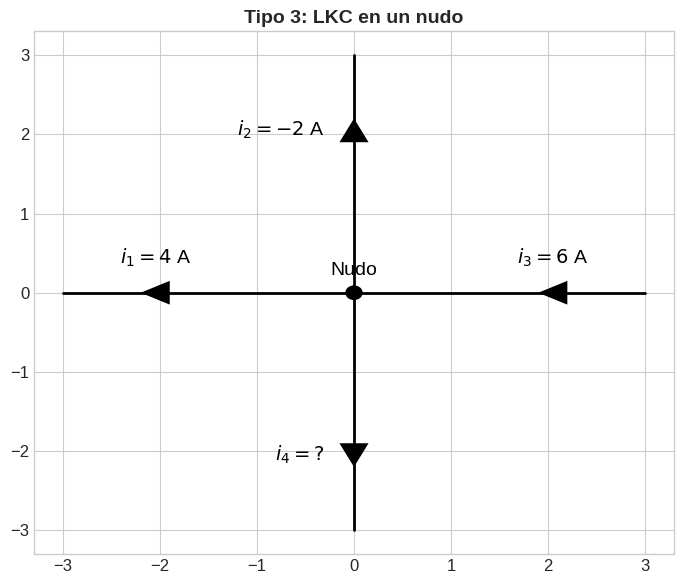

In [9]:
# Tipo 3: diagrama de nudo con corrientes
fig, ax = plt.subplots(figsize=(7, 6))
ax.set_title('Tipo 3: LKC en un nudo', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)

# Nudo central
d += elm.Dot().label(r'Nudo', loc='top')
center = d.here

# Rama 1: izquierda (entra)
d += elm.Line().left().at(center).length(3)
d += elm.CurrentLabelInline(direction='in').label(r'$i_1 = 4$ A')

# Rama 2: arriba (sale)
d += elm.Line().up().at(center).length(3)
d += elm.CurrentLabelInline(direction='in').label(r'$i_2 = -2$ A')

# Rama 3: derecha (entra)
d += elm.Line().right().at(center).length(3)
d += elm.CurrentLabelInline(direction='out').label(r'$i_3 = 6$ A')

# Rama 4: abajo (sale)
d += elm.Line().down().at(center).length(3)
d += elm.CurrentLabelInline(direction='in').label(r'$i_4 = ?$')

d.draw()
plt.tight_layout()
plt.show()

### 10.4 Tipo 4: LKC en un corte

$$\boxed{\sum_k i_k = 0 \quad \text{(en un corte)}}$$

**Idea clave:** un **corte** es un conjunto de ramas que, al eliminarlas, divide el circuito en dos partes. La LKC se aplica igual que en un nudo: la suma de corrientes que cruzan el corte (en un sentido menos las del otro) es cero.

**Diferencia con nudo:** un corte puede englobar varios nodos. La LKC en un corte es una **combinación lineal** de las LKC de los nodos internos.

#### Ejercicio resuelto: Tipo 4

**Datos:** Corte que separa una región con corrientes salientes $i_A = 3\;\text{A}$, $i_B = 7\;\text{A}$ y entrante $i_C$. 

$$i_C - i_A - i_B = 0 \implies i_C = 3 + 7 = 10\;\text{A}$$

$$\boxed{i_C = 10\;\text{A}\;\text{(entrando por el corte)}}$$

### 10.5 Tipo 5: LKT en un bucle

$$\boxed{\sum_k u_k = 0 \quad \text{(en un bucle)}}$$

**Idea clave:** al recorrer un camino cerrado (bucle), la suma algebraica de tensiones es cero. El bucle puede contener otros bucles dentro (a diferencia de la malla).

**Cómo se aplica:**
1. Elegir un sentido de recorrido (horario o antihorario)
2. Recorrer el bucle y sumar tensiones: $+u$ si el terminal $+$ aparece primero, $-u$ si aparece el $-$ primero
3. Igualar a cero y despejar

#### Ejercicio resuelto: Tipo 5

**Datos:** Bucle exterior de un circuito con $u_1 = 12\;\text{V}$, $u_2 = 3\;\text{V}$, $u_3 = 5\;\text{V}$, $u_4 = ?$ (recorrido horario).

$$u_1 - u_2 - u_3 - u_4 = 0 \implies u_4 = 12 - 3 - 5 = 4\;\text{V}$$

$$\boxed{u_4 = 4\;\text{V}}$$

### 10.6 Tipo 6: LKT en una malla

$$\boxed{\sum_k u_k = 0 \quad \text{(en una malla)}}$$

**Idea clave:** una malla es un bucle que **no contiene** ningún otro bucle en su interior. En un circuito plano, las mallas son las "ventanas" del circuito.

**Diferencia con bucle:** el número de mallas independientes determina el número mínimo de ecuaciones de LKT necesarias.

#### Ejercicio resuelto: Tipo 6

**Datos:** Malla con fuente $V_s = 10\;\text{V}$, y dos resistencias $R_1 = 2\;\Omega$, $R_2 = 3\;\Omega$ en serie. Corriente $i$ desconocida.

$$V_s - R_1 \cdot i - R_2 \cdot i = 0 \implies i = \frac{V_s}{R_1 + R_2} = \frac{10}{2 + 3} = 2\;\text{A}$$

$$\boxed{i = 2\;\text{A}}$$

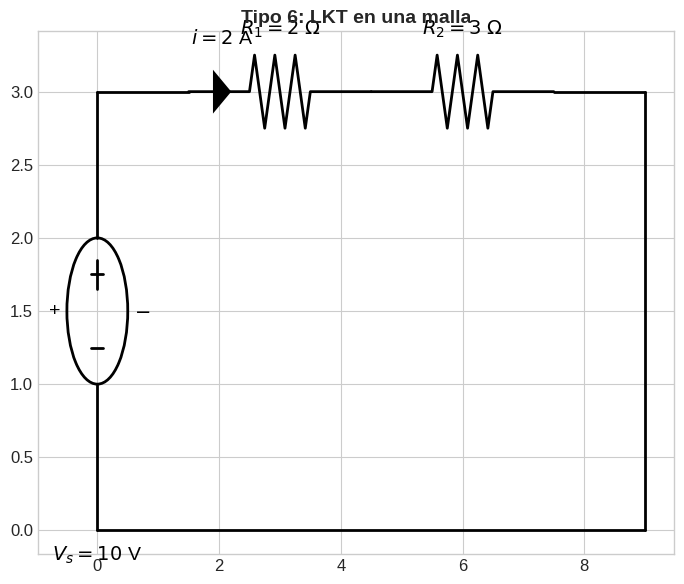

In [10]:
# Tipo 6: diagrama de malla simple
fig, ax = plt.subplots(figsize=(7, 6))
ax.set_title('Tipo 6: LKT en una malla', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)

# Fuente a la izquierda
d += (Vs := elm.SourceV().up().label(r'$V_s = 10$ V', loc='left').label('+', loc='top').label('$-$', loc='bottom'))

# Línea superior
d += elm.Line().right().length(1.5)

# R1
d += (R1 := elm.Resistor().right().label(r'$R_1 = 2\;\Omega$'))

# R2
d += (R2 := elm.Resistor().right().label(r'$R_2 = 3\;\Omega$'))

# Línea bajando
d += elm.Line().right().length(1.5)
d += elm.Line().down().toy(Vs.start)

# Línea inferior
d += elm.Line().left().tox(Vs.start)

# Corriente
d += elm.CurrentLabelInline(direction='in').at(R1).label(r'$i = 2$ A')

d.draw()
plt.tight_layout()
plt.show()

### 10.7 Tipo 7: LKC + LKT combinadas

$$\boxed{\text{Sistema de ecuaciones con LKC (nodos) + LKT (mallas)}}$$

**Idea clave:** los circuitos con múltiples mallas y nodos requieren **combinar** varias ecuaciones de LKC y LKT para formar un sistema de ecuaciones. Este es el tipo de ejercicio más completo y más frecuente en exámenes.

**Metodología:**
1. Asignar referencias de corriente y tensión a cada elemento
2. Escribir LKC en cada nudo independiente
3. Escribir LKT en cada malla independiente
4. Resolver el sistema de ecuaciones

#### Ejercicio resuelto: Tipo 7

**Datos:** Circuito con $V_s = 20\;\text{V}$, $R_1 = 5\;\Omega$, $R_2 = 10\;\Omega$, $R_3 = 10\;\Omega$. $R_2$ y $R_3$ en paralelo, el conjunto en serie con $R_1$.

**Paso 1:** LKC en el nudo superior (donde se bifurca la corriente):

$$i_1 = i_2 + i_3$$

**Paso 2:** LKT en malla 1 ($V_s$, $R_1$, $R_2$):

$$V_s - R_1 \cdot i_1 - R_2 \cdot i_2 = 0 \implies 20 - 5i_1 - 10i_2 = 0$$

**Paso 3:** LKT en malla 2 ($R_2$, $R_3$):

$$R_2 \cdot i_2 - R_3 \cdot i_3 = 0 \implies 10i_2 = 10i_3 \implies i_2 = i_3$$

**Paso 4:** Sustituyendo $i_3 = i_2$ en LKC: $i_1 = 2i_2$. Sustituyendo en LKT malla 1:

$$20 - 5(2i_2) - 10i_2 = 0 \implies 20 = 20i_2 \implies i_2 = 1\;\text{A}$$

$$\boxed{i_1 = 2\;\text{A}, \quad i_2 = i_3 = 1\;\text{A}}$$

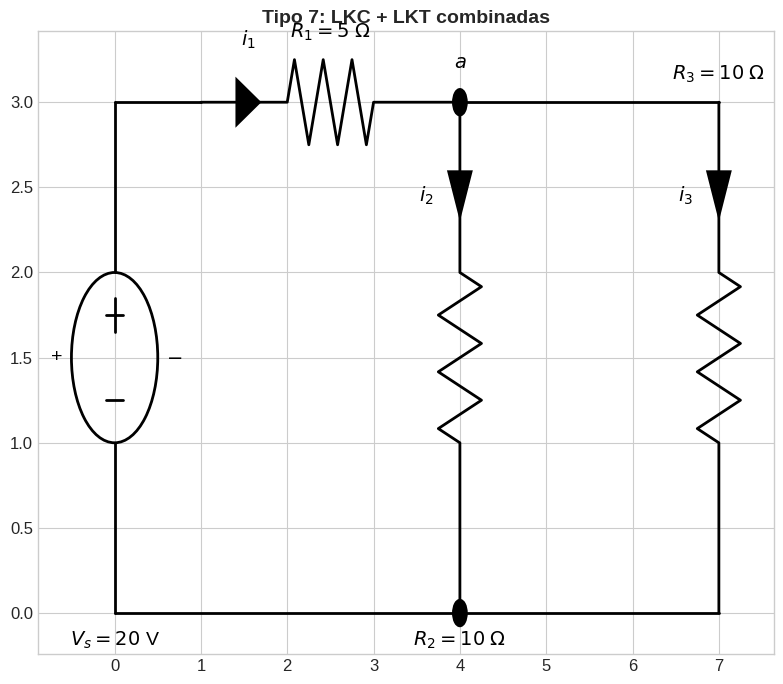

In [11]:
# Tipo 7: circuito con R2 y R3 en paralelo, serie con R1
fig, ax = plt.subplots(figsize=(8, 7))
ax.set_title('Tipo 7: LKC + LKT combinadas', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)

# Fuente a la izquierda
d += (Vs := elm.SourceV().up().label(r'$V_s = 20$ V', loc='left').label('+', loc='top').label('$-$', loc='bottom'))

# R1 arriba
d += elm.Line().right().length(1)
d += (R1 := elm.Resistor().right().label(r'$R_1 = 5\;\Omega$'))
nodo_sup = d.here
d += elm.Dot().label(r'$a$', loc='top')

# R2 baja desde nodo_sup
d += (R2 := elm.Resistor().down().at(nodo_sup).label(r'$R_2 = 10\;\Omega$', loc='left'))
nodo_inf = d.here
d += elm.Dot()

# R3 a la derecha de nodo_sup, baja
d += elm.Line().right().at(nodo_sup).length(3)
d += (R3 := elm.Resistor().down().label(r'$R_3 = 10\;\Omega$', loc='right'))

# Línea inferior
d += elm.Line().left().tox(nodo_inf)
d += elm.Line().left().at(nodo_inf).tox(Vs.start)
d += elm.Line().up().toy(Vs.start)

# Corrientes
d += elm.CurrentLabelInline(direction='in').at(R1).label(r'$i_1$')
d += elm.CurrentLabelInline(direction='in').at(R2).label(r'$i_2$')
d += elm.CurrentLabelInline(direction='in').at(R3).label(r'$i_3$')

d.draw()
plt.tight_layout()
plt.show()

### 10.8 Tipo 8: Balance de potencia

$$\boxed{\sum_k p_k = 0 \quad \text{(potencia total = 0)}}$$

**Idea clave:** la potencia total absorbida en un circuito debe ser igual a la potencia total entregada. Si la suma no da cero, hay un error en los cálculos.

**Cómo se calcula:**
- Para cada elemento con referencia **pasiva**: $p = u \cdot i$ ($+$ si absorbe, $-$ si entrega)
- Para fuentes con referencia **activa**: $p = u \cdot i$ ($+$ si entrega, $-$ si absorbe)

#### Ejercicio resuelto: Tipo 8

**Datos:** Circuito con $V_s = 24\;\text{V}$, $R_1 = 6\;\Omega$, $R_2 = 12\;\Omega$ en paralelo.

**Paso 1:** Tensión en las resistencias (paralelo): $u_{R_1} = u_{R_2} = V_s = 24\;\text{V}$

**Paso 2:** Corrientes:

$$i_1 = \frac{V_s}{R_1} = \frac{24}{6} = 4\;\text{A}, \quad i_2 = \frac{V_s}{R_2} = \frac{24}{12} = 2\;\text{A}$$

**Paso 3:** Potencias:

$$p_{R_1} = 24 \times 4 = 96\;\text{W (absorbe)}, \quad p_{R_2} = 24 \times 2 = 48\;\text{W (absorbe)}$$

$$p_{V_s} = 24 \times (4+2) = 24 \times 6 = 144\;\text{W (entrega)}$$

**Paso 4:** Balance: $96 + 48 - 144 = 0\;\checkmark$

$$\boxed{\sum p_k = 96 + 48 - 144 = 0\;\text{W}}$$

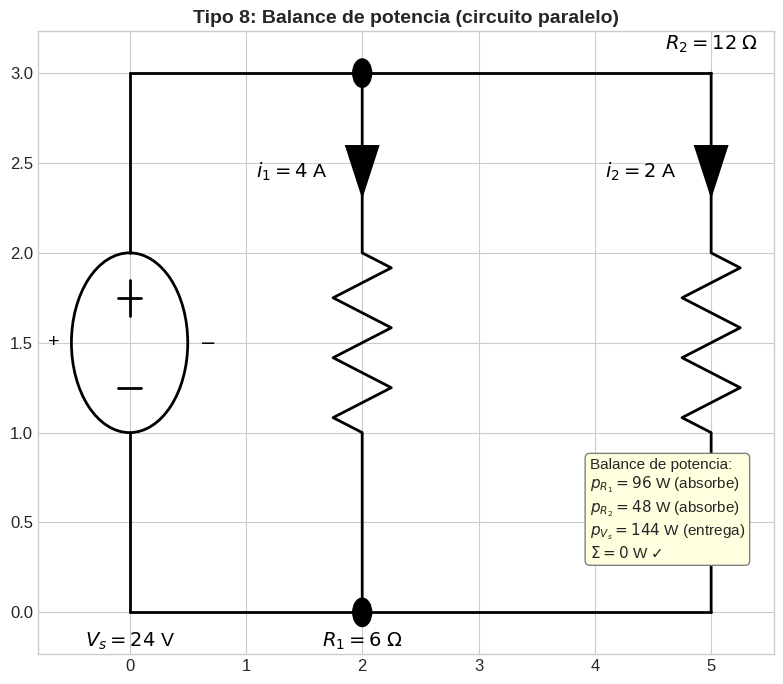

In [12]:
# Tipo 8: diagrama circuito paralelo para balance de potencia
fig, ax = plt.subplots(figsize=(8, 7))
ax.set_title('Tipo 8: Balance de potencia (circuito paralelo)', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)

# Fuente a la izquierda
d += (Vs := elm.SourceV().up().label(r'$V_s = 24$ V', loc='left').label('+', loc='top').label('$-$', loc='bottom'))
top_left = d.here

# Línea superior
d += elm.Line().right().length(2)
nodo_top = d.here
d += elm.Dot()

# R1 baja
d += (R1 := elm.Resistor().down().at(nodo_top).label(r'$R_1 = 6\;\Omega$', loc='left'))
nodo_bot = d.here
d += elm.Dot()

# R2 a la derecha, baja
d += elm.Line().right().at(nodo_top).length(3)
d += (R2 := elm.Resistor().down().label(r'$R_2 = 12\;\Omega$', loc='right'))

# Líneas inferiores
d += elm.Line().left().tox(nodo_bot)
d += elm.Line().left().at(nodo_bot).tox(Vs.start)
d += elm.Line().up().toy(Vs.start)

# Corrientes
d += elm.CurrentLabelInline(direction='in').at(R1).label(r'$i_1 = 4$ A')
d += elm.CurrentLabelInline(direction='in').at(R2).label(r'$i_2 = 2$ A')

d.draw()

# Tabla de potencias
tabla = ('Balance de potencia:\n'
         r'$p_{R_1} = 96$ W (absorbe)' + '\n'
         r'$p_{R_2} = 48$ W (absorbe)' + '\n'
         r'$p_{V_s} = 144$ W (entrega)' + '\n'
         r'$\Sigma = 0$ W $\checkmark$')
ax.text(0.75, 0.15, tabla, fontsize=11, transform=ax.transAxes,
        verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='gray'))

plt.tight_layout()
plt.show()

### 10.9 Tipo 9: Determinar si absorbe o entrega potencia

$$\boxed{p = u \cdot i \quad \text{(ref. pasiva: } p>0 \to \text{absorbe, } p<0 \to \text{entrega)}}$$

**Idea clave:** el signo de $p = u \cdot i$ depende del **convenio de referencia** usado. Siempre hay que especificar si se usa referencia pasiva o activa.

**Truco para el examen:**
- Referencia **pasiva** (corriente entra por $+$): $p > 0$ = absorbe
- Referencia **activa** (corriente sale por $+$): $p > 0$ = entrega
- Si obtienes un resultado negativo, el elemento hace lo **contrario** de lo que indica la referencia

#### Ejercicio resuelto: Tipo 9

**Datos:** Elemento con $u = 8\;\text{V}$ y $i = -3\;\text{A}$ en referencia pasiva.

$$p = u \cdot i = 8 \times (-3) = -24\;\text{W}$$

Como $p < 0$ en referencia pasiva $\to$ el elemento **entrega** $24\;\text{W}$.

$$\boxed{p = -24\;\text{W (entrega 24 W)}}$$

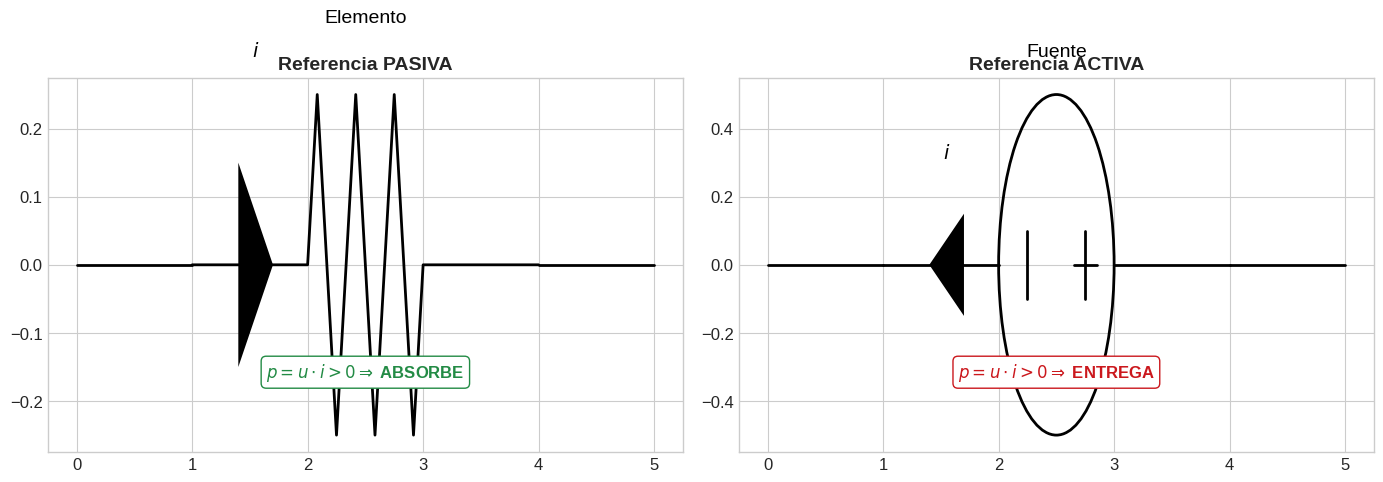

In [13]:
# Tipo 9: diagrama referencia pasiva vs activa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Referencia pasiva
axes[0].set_title('Referencia PASIVA', fontsize=14, fontweight='bold')
d1 = schemdraw.Drawing(canvas=axes[0])
d1 += elm.Line().right().length(1)
d1 += (elem1 := elm.Resistor().right().label(r'Elemento', loc='top'))
d1 += elm.Line().right().length(1)
d1 += elm.CurrentLabelInline(direction='in').at(elem1).label(r'$i$')
axes[0].text(0.5, 0.2, r'$p = u \cdot i > 0 \Rightarrow$ ABSORBE', fontsize=12,
             ha='center', transform=axes[0].transAxes, color=COLOR_PUNTO, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_PUNTO))
d1.draw()

# Referencia activa
axes[1].set_title('Referencia ACTIVA', fontsize=14, fontweight='bold')
d2 = schemdraw.Drawing(canvas=axes[1])
d2 += elm.Line().right().length(1)
d2 += (elem2 := elm.SourceV().right().label(r'Fuente', loc='top'))
d2 += elm.Line().right().length(1)
d2 += elm.CurrentLabelInline(direction='out').at(elem2).label(r'$i$')
axes[1].text(0.5, 0.2, r'$p = u \cdot i > 0 \Rightarrow$ ENTREGA', fontsize=12,
             ha='center', transform=axes[1].transAxes, color=COLOR_RECTA, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_RECTA))
d2.draw()

plt.tight_layout()
plt.show()

### 10.10 Tipo 10: Encontrar el circuito dual

$$\boxed{\text{Sustituir cada magnitud por su dual en la tabla de dualidad}}$$

**Idea clave:** la dualidad transforma un circuito en otro cuyas ecuaciones son las mismas pero con las variables intercambiadas. Es especialmente útil porque si ya sabes resolver un tipo de circuito, sabes resolver su dual automáticamente.

**Pasos:**
1. Escribir las ecuaciones del circuito original
2. Sustituir cada magnitud por su dual (ver tabla de la sección 7)
3. El circuito que satisface las nuevas ecuaciones es el dual

#### Ejercicio resuelto: Tipo 10

**Datos:** Circuito serie con fuente de tensión $V_s = 10\;\text{V}$, resistencia $R = 5\;\Omega$ y condensador $C = 2\;\text{F}$.

**Ecuación original (LKT):**

$$V_s = R \cdot i + \frac{1}{C}\int i\,dt$$

**Circuito dual** (sustituir magnitudes duales):
- $V_s \to I_s = 10\;\text{A}$ (fuente de corriente)
- $R \to G = 5\;\text{S}$ (conductancia)
- $C \to L = 2\;\text{H}$ (inductancia)
- Serie $\to$ Paralelo
- LKT $\to$ LKC

**Ecuación dual (LKC):**

$$I_s = G \cdot u + \frac{1}{L}\int u\,dt$$

$$\boxed{\text{Dual: } I_s = 10\;\text{A en paralelo con } G = 5\;\text{S y } L = 2\;\text{H}}$$

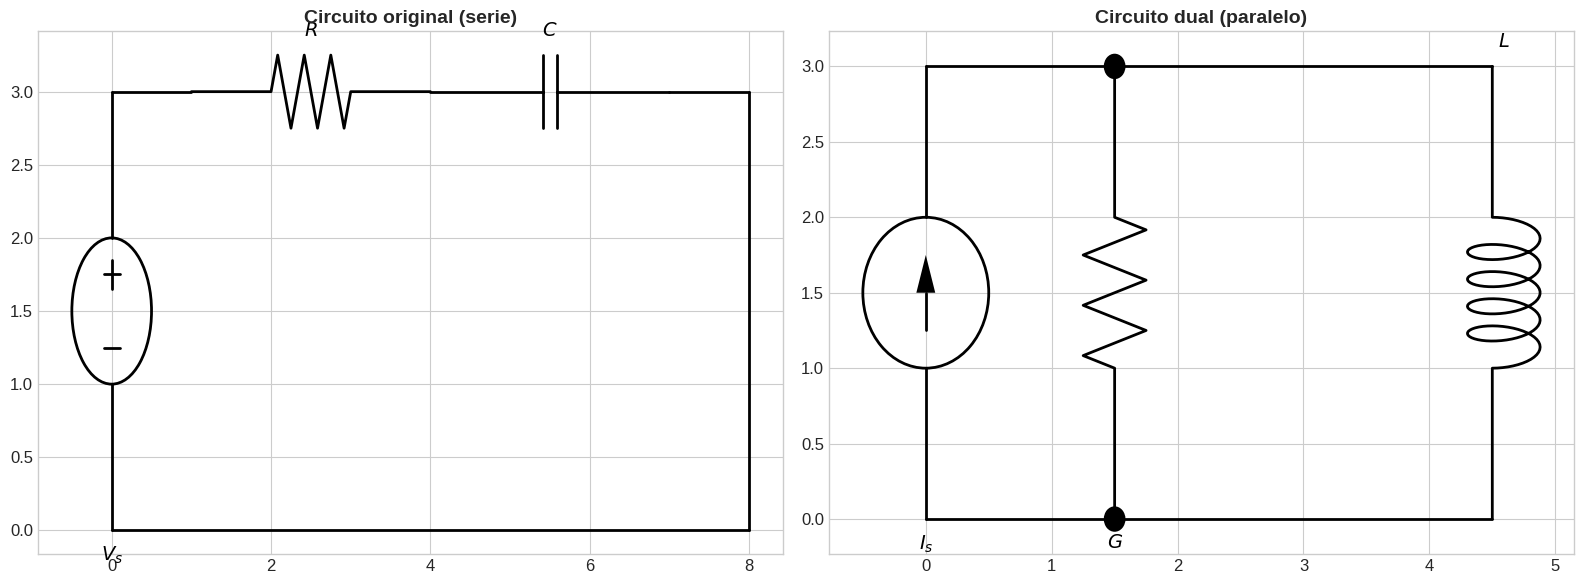

In [14]:
# Tipo 10: circuito original (serie) y su dual (paralelo)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Circuito original: serie
axes[0].set_title('Circuito original (serie)', fontsize=14, fontweight='bold')
d1 = schemdraw.Drawing(canvas=axes[0])
d1 += (Vs := elm.SourceV().up().label(r'$V_s$', loc='left'))
d1 += elm.Line().right().length(1)
d1 += elm.Resistor().right().label(r'$R$')
d1 += elm.Capacitor().right().label(r'$C$')
d1 += elm.Line().right().length(1)
d1 += elm.Line().down().toy(Vs.start)
d1 += elm.Line().left().tox(Vs.start)
d1.draw()

# Circuito dual: paralelo
axes[1].set_title('Circuito dual (paralelo)', fontsize=14, fontweight='bold')
d2 = schemdraw.Drawing(canvas=axes[1])
d2 += (Is := elm.SourceI().up().label(r'$I_s$', loc='left'))
top = d2.here

d2 += elm.Line().right().length(1.5)
nodo = d2.here
d2 += elm.Dot()

# G baja
d2 += elm.Resistor().down().at(nodo).label(r'$G$', loc='left')
nodo_b = d2.here
d2 += elm.Dot()

# L a la derecha, baja
d2 += elm.Line().right().at(nodo).length(3)
d2 += elm.Inductor2().down().label(r'$L$', loc='right')

# Cierre
d2 += elm.Line().left().tox(nodo_b)
d2 += elm.Line().left().at(nodo_b).tox(Is.start)
d2 += elm.Line().up().toy(Is.start)
d2.draw()

plt.tight_layout()
plt.show()

### Tabla resumen: fórmulas por tipo de ejercicio

| # | Tipo | Fórmula clave | Qué hay que hacer |
|---|------|---------------|-------------------|
| 1 | Carga desde corriente | $\dfrac{}{}q = \int i\,dt$ | Integrar $i(t)$ en el intervalo |
| 2 | Energía desde potencia | $W = P \cdot t$ o $W = \int p\,dt$ | Multiplicar o integrar |
| 3 | LKC en nudo | $\sum i_k = 0$ | Sumar corrientes (signo por sentido) |
| 4 | LKC en corte | $\sum i_k = 0$ | Igual que nudo pero en corte |
| 5 | LKT en bucle | $\sum u_k = 0$ | Sumar tensiones recorriendo bucle |
| 6 | LKT en malla | $\sum u_k = 0$ | Igual que bucle pero en malla |
| 7 | LKC + LKT | Sistema de ecuaciones | Combinar ecuaciones de nudo y malla |
| 8 | Balance de potencia | $\sum p_k = 0$ | Calcular $p = u \cdot i$ de cada elemento |
| 9 | Absorbe/entrega | Signo de $p = u \cdot i$ | Verificar signo y referencia |
| 10 | Circuito dual | Tabla de dualidad | Sustituir cada magnitud por su dual |

---

## 11. Resumen y tabla de fórmulas clave

| Fórmula clave | Uso |
|---------------|-----|
| $\boxed{i(t) = \dfrac{dq}{dt}}$ | Corriente como derivada de la carga |
| $\boxed{u(t) = \dfrac{dw}{dq}}$ | Tensión como derivada de la energía respecto a la carga |
| $\boxed{u(t) = \dfrac{d\varphi}{dt}}$ | Ley de Faraday: tensión como derivada del flujo |
| $\boxed{p(t) = u(t) \cdot i(t)}$ | Potencia instantánea |
| $\boxed{w(t) = \int p(\tau)\,d\tau}$ | Energía como integral de la potencia |
| $\boxed{\sum_k i_k = 0}$ | **LKC:** suma de corrientes en nudo o corte = 0 |
| $\boxed{\sum_k u_k = 0}$ | **LKT:** suma de tensiones en bucle o malla = 0 |
| $\boxed{\sum_k p_k = 0}$ | **Balance de potencia:** potencia total = 0 |

### Conceptos clave para el examen

1. **LKC** se aplica en **nudos** y **cortes** (conservación de la carga)
2. **LKT** se aplica en **bucles** y **mallas** (conservación de la energía)
3. Una **malla** es un bucle sin bucles interiores
4. Un **corte** separa el circuito en dos partes
5. La **referencia de polaridad** es solo un convenio de signos
6. El **balance de potencia** sirve para verificar cálculos
7. La **dualidad** intercambia tensión/corriente, serie/paralelo, malla/nudo